# Plot Predicted Mass Spectra

This notebook visualizes the predicted EI mass spectra from the Massformer model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from rdkit import Chem
from rdkit.Chem import Draw

%matplotlib inline

## Load Predictions

In [2]:
# Load the predictions
df = pd.read_csv("out.csv")

# Parse the peaks column (it's stored as string representation of list)
df["peaks"] = df["peaks"].apply(ast.literal_eval)

print(f"Loaded {len(df)} predictions")
df.head()

Loaded 3 predictions


,spec_id,mol_id,group_id,prec_type,prec_mz,nce,inst_type,frag_mode,spec_type,ion_mode,peaks
0,0,0,0,EI,46.041865,0.0,EI-GC,EI,EI,EI,"[(12.0, 0.00035498376), (13.0, 0.0020913638), ..."
1,1,1,1,EI,58.078250,0.0,EI-GC,EI,EI,EI,"[(12.0, 5.8967467e-05), (13.0, 0.00072010676),..."
2,2,2,2,EI,78.046950,0.0,EI-GC,EI,EI,EI,"[(12.0, 0.00031007215), (13.0, 0.0003816566), ..."


## Load Original SMILES

In [3]:
# Load the original SMILES file to get molecule information
smiles_df = pd.read_csv("smiles.csv")
print(f"Loaded {len(smiles_df)} molecules")
smiles_df.head()

Loaded 3 molecules


,mol_id,smiles
0,0,CCO
1,1,CCCC
2,2,c1ccccc1


## Helper Functions

In [4]:
def plot_spectrum(
    peaks, title=None, ax=None, color="steelblue", show_mz_labels=True
):
    """
    Plot a mass spectrum from a list of (m/z, intensity) tuples.

    Args:
        peaks: List of (m/z, intensity) tuples
        title: Title for the plot
        ax: Matplotlib axis to plot on (creates new if None)
        color: Color for the spectrum bars
        show_mz_labels: Whether to show m/z labels for top peaks
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    if len(peaks) == 0:
        ax.text(
            0.5,
            0.5,
            "No peaks predicted",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return ax

    # Extract m/z and intensities
    mzs = np.array([p[0] for p in peaks])
    intensities = np.array([p[1] for p in peaks])

    # Normalize intensities to 100
    if intensities.max() > 0:
        intensities = 100 * intensities / intensities.max()

    # Plot stems
    markerline, stemlines, baseline = ax.stem(
        mzs, intensities, linefmt=color, markerfmt=" ", basefmt=" "
    )
    plt.setp(stemlines, "linewidth", 1.5)

    # Annotate top peaks
    if show_mz_labels:
        # Find top 5 peaks
        top_indices = np.argsort(intensities)[-5:]
        for idx in top_indices:
            if intensities[idx] > 5:  # Only label if intensity > 5%
                ax.annotate(
                    f"{int(mzs[idx])}",
                    xy=(mzs[idx], intensities[idx]),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha="center",
                    fontsize=9,
                    color=color,
                )

    ax.set_xlabel("m/z", fontsize=12)
    ax.set_ylabel("Relative Intensity (%)", fontsize=12)
    ax.set_ylim(0, 110)
    ax.set_xlim(0, max(mzs) * 1.05 if len(mzs) > 0 else 800)
    ax.grid(True, alpha=0.3)

    if title:
        ax.set_title(title, fontsize=14, fontweight="bold")

    return ax


def plot_spectrum_with_molecule(mol_id, peaks, smiles, figsize=(14, 6)):
    """
    Plot spectrum alongside molecular structure.

    Args:
        mol_id: Molecule ID
        peaks: List of (m/z, intensity) tuples
        smiles: SMILES string
        figsize: Figure size
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.3)

    # Plot molecule structure
    ax_mol = fig.add_subplot(gs[0])
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            img = Draw.MolToImage(mol, size=(400, 400))
            ax_mol.imshow(img)
            ax_mol.axis("off")
            ax_mol.set_title(
                f"Molecule {mol_id}\n{smiles[:50]}...", fontsize=10, wrap=True
            )
        else:
            ax_mol.text(
                0.5,
                0.5,
                "Invalid SMILES",
                ha="center",
                va="center",
                transform=ax_mol.transAxes,
            )
            ax_mol.axis("off")
    except Exception as e:
        ax_mol.text(
            0.5,
            0.5,
            f"Error: {str(e)}",
            ha="center",
            va="center",
            transform=ax_mol.transAxes,
        )
        ax_mol.axis("off")

    # Plot spectrum
    ax_spec = fig.add_subplot(gs[1])
    plot_spectrum(
        peaks,
        title=f"Predicted EI-MS Spectrum (mol_id={mol_id})",
        ax=ax_spec,
        color="steelblue",
    )

    plt.tight_layout()
    return fig


def summarize_spectrum(peaks):
    """
    Print summary statistics for a spectrum.
    """
    if len(peaks) == 0:
        print("No peaks in spectrum")
        return

    mzs = np.array([p[0] for p in peaks])
    intensities = np.array([p[1] for p in peaks])

    print(f"Number of peaks: {len(peaks)}")
    print(f"m/z range: {mzs.min():.1f} - {mzs.max():.1f}")
    print(
        f"Base peak (highest intensity): m/z = {mzs[intensities.argmax()]:.1f}"
    )
    print(f"\nTop 5 peaks:")
    top_5_idx = np.argsort(intensities)[-5:][::-1]
    for idx in top_5_idx:
        rel_int = 100 * intensities[idx] / intensities.max()
        print(f"  m/z = {mzs[idx]:.1f}, intensity = {rel_int:.1f}%")

## Plot All Predicted Spectra


Molecule 0: CCO
Number of peaks: 23
m/z range: 12.0 - 46.0
Base peak (highest intensity): m/z = 45.0

Top 5 peaks:
  m/z = 45.0, intensity = 100.0%
  m/z = 31.0, intensity = 72.3%
  m/z = 29.0, intensity = 52.5%
  m/z = 27.0, intensity = 18.0%
  m/z = 28.0, intensity = 15.7%


/tmp/ipykernel_2091691/3526842223.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


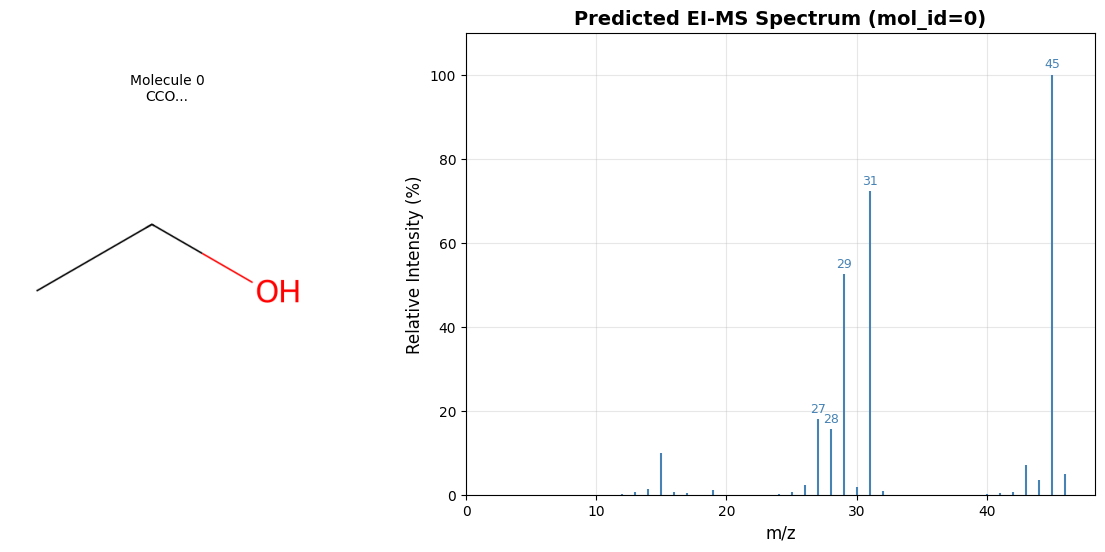



Molecule 1: CCCC
Number of peaks: 33
m/z range: 12.0 - 58.0
Base peak (highest intensity): m/z = 29.0

Top 5 peaks:
  m/z = 29.0, intensity = 100.0%
  m/z = 27.0, intensity = 75.5%
  m/z = 43.0, intensity = 50.5%
  m/z = 39.0, intensity = 32.3%
  m/z = 58.0, intensity = 27.1%


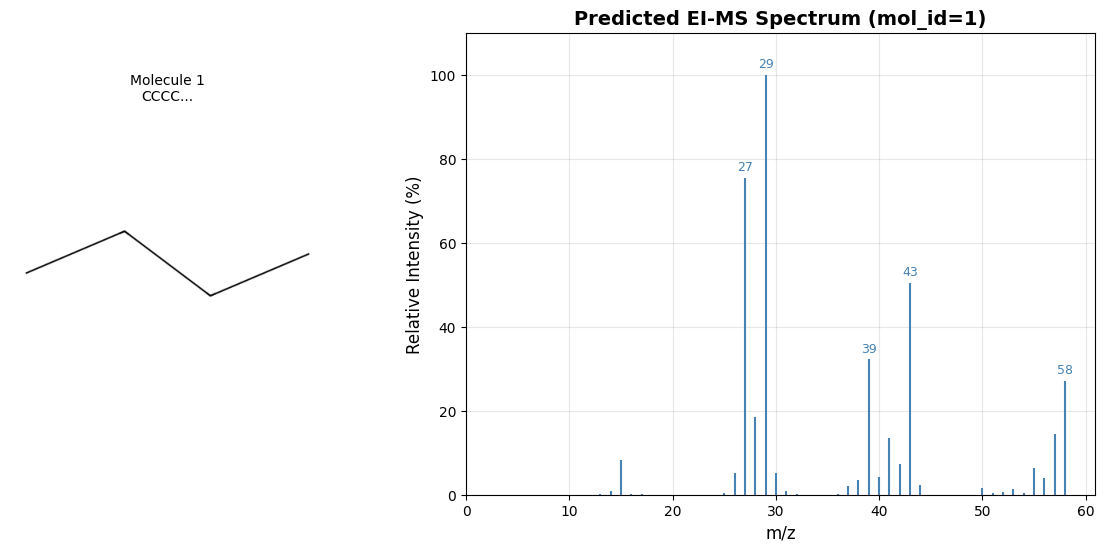



Molecule 2: c1ccccc1
Number of peaks: 39
m/z range: 12.0 - 78.0
Base peak (highest intensity): m/z = 78.0

Top 5 peaks:
  m/z = 78.0, intensity = 100.0%
  m/z = 77.0, intensity = 67.5%
  m/z = 51.0, intensity = 32.3%
  m/z = 50.0, intensity = 26.1%
  m/z = 52.0, intensity = 8.4%


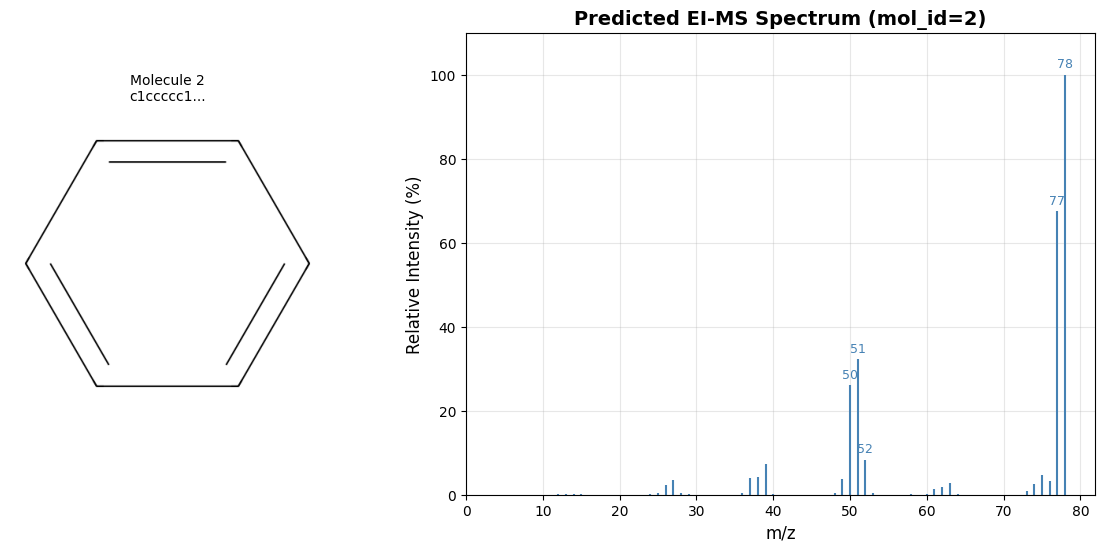

In [5]:
# Plot each predicted spectrum with its molecular structure
for idx, row in df.iterrows():
    mol_id = row["mol_id"]
    peaks = row["peaks"]

    # Get SMILES from original file
    smiles_row = smiles_df[smiles_df["mol_id"] == mol_id]
    if len(smiles_row) > 0:
        smiles = smiles_row.iloc[0]["smiles"]
    else:
        smiles = "Unknown"

    print(f"\n{'=' * 80}")
    print(f"Molecule {mol_id}: {smiles}")
    print("=" * 80)

    # Summary statistics
    summarize_spectrum(peaks)

    # Plot
    plot_spectrum_with_molecule(mol_id, peaks, smiles)
    plt.show()
    print()

## Compare All Spectra Side-by-Side

Saved comparison plot to 'all_predictions.png'


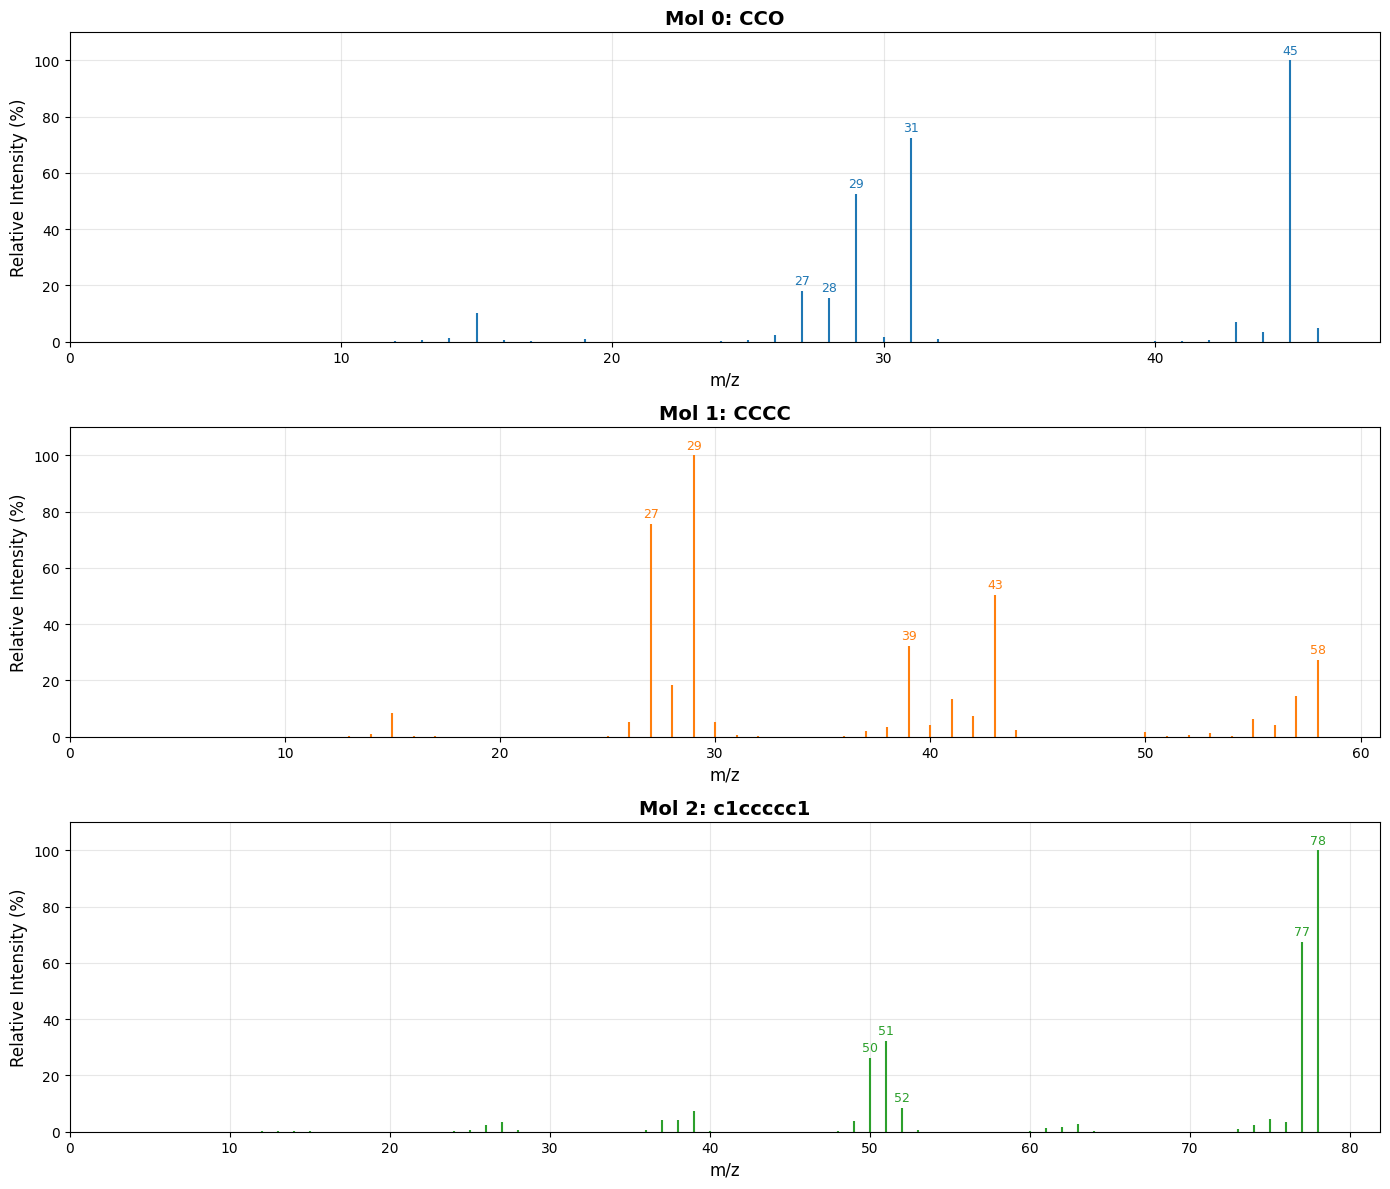

In [6]:
# Create a grid of all spectra for comparison
n_spectra = len(df)
fig, axes = plt.subplots(n_spectra, 1, figsize=(14, 4 * n_spectra))

if n_spectra == 1:
    axes = [axes]

for idx, (ax, (_, row)) in enumerate(zip(axes, df.iterrows())):
    mol_id = row["mol_id"]
    peaks = row["peaks"]

    # Get SMILES
    smiles_row = smiles_df[smiles_df["mol_id"] == mol_id]
    if len(smiles_row) > 0:
        smiles = smiles_row.iloc[0]["smiles"]
        title = f"Mol {mol_id}: {smiles[:60]}"
    else:
        title = f"Mol {mol_id}"

    plot_spectrum(
        peaks, title=title, ax=ax, color=f"C{idx}", show_mz_labels=True
    )

plt.tight_layout()
plt.savefig("all_predictions.png", dpi=300, bbox_inches="tight")
print("Saved comparison plot to 'all_predictions.png'")
plt.show()

## Export Peak Lists

In [7]:
# Export peak lists in a more readable format
for idx, row in df.iterrows():
    mol_id = row["mol_id"]
    peaks = row["peaks"]

    # Get SMILES
    smiles_row = smiles_df[smiles_df["mol_id"] == mol_id]
    if len(smiles_row) > 0:
        smiles = smiles_row.iloc[0]["smiles"]
    else:
        smiles = "Unknown"

    # Create peak table
    peak_df = pd.DataFrame(peaks, columns=["mz", "intensity"])
    peak_df = peak_df.sort_values("intensity", ascending=False)
    peak_df["relative_intensity"] = (
        100 * peak_df["intensity"] / peak_df["intensity"].max()
    )

    print(f"\nMolecule {mol_id}: {smiles}")
    print(peak_df.head(10).to_string(index=False))


Molecule 0: CCO
  mz  intensity  relative_intensity
45.0   0.338788          100.000000
31.0   0.245047           72.330605
29.0   0.177899           52.510440
27.0   0.061052           18.020595
28.0   0.053041           15.655975
15.0   0.034044           10.048630
43.0   0.024069            7.104528
46.0   0.016462            4.858940
44.0   0.011821            3.489109
26.0   0.007926            2.339542

Molecule 1: CCCC
  mz  intensity  relative_intensity
29.0   0.257576          100.000000
27.0   0.194473           75.501172
43.0   0.130059           50.493680
39.0   0.083236           32.315024
58.0   0.069859           27.121694
28.0   0.047423           18.411258
57.0   0.037416           14.526199
41.0   0.034706           13.473960
15.0   0.021483            8.340443
42.0   0.019003            7.377798

Molecule 2: c1ccccc1
  mz  intensity  relative_intensity
78.0   0.356495          100.000000
77.0   0.240576           67.483822
51.0   0.115040           32.269844
50.0   

## Save Individual Spectra to Files

In [8]:
import os

# Create output directory
output_dir = "predicted_spectra"
os.makedirs(output_dir, exist_ok=True)

# Save each spectrum as a separate image
for idx, row in df.iterrows():
    mol_id = row["mol_id"]
    peaks = row["peaks"]

    # Get SMILES
    smiles_row = smiles_df[smiles_df["mol_id"] == mol_id]
    if len(smiles_row) > 0:
        smiles = smiles_row.iloc[0]["smiles"]
    else:
        smiles = "Unknown"

    # Plot and save
    fig = plot_spectrum_with_molecule(mol_id, peaks, smiles)
    output_path = os.path.join(output_dir, f"mol_{mol_id}_spectrum.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {output_path}")

print(f"\nAll spectra saved to '{output_dir}/' directory")

/tmp/ipykernel_2091691/3526842223.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: predicted_spectra/mol_0_spectrum.png
Saved: predicted_spectra/mol_1_spectrum.png
Saved: predicted_spectra/mol_2_spectrum.png

All spectra saved to 'predicted_spectra/' directory
